# Case study: sc-SVC analysis of fine-grained TAM states in Xenium data

## Notebook Guide

**Purpose.** Preserve and explain the sc-SVC analysis workflow for the Xenium monocyte/macrophage dataset.

**Inputs.** Use either the real-world ST raw data required for reconstruction or the released monocyte/macrophage `spatial.h5ad` / `expr.h5ad` pair described below; the CCI block also consumes the T expression-side object.

### Two ways to obtain the analysis inputs

1. **Reconstruct locally.** Download the [Real-world ST datasets](https://zenodo.org/records/21921802), place `P2CRC_Xenium.h5ad` and `adata_sc_all_reanno.h5ad` under `../../raw_data/Real_application/`, and run `python reconstruct.py --config configs/application/Xenium.yaml --select-ct Mono_Macro` from the repository root.
2. **Start from released results.** Download the [REVISE-reconstructed sc-SVC Xenium data](https://zenodo.org/records/18389211) and place the monocyte/macrophage pair at `../../results/sc_SVC_case/P2CRC_Xenium/Mono_Macro/spatial.h5ad` and `../../results/sc_SVC_case/P2CRC_Xenium/Mono_Macro/expr.h5ad`. Then begin with **Load the reconstructed TAM objects** below.

**Reconstruction input.** The route starts from `../../raw_data/Real_application/P2CRC_Xenium.h5ad` and `../../raw_data/Real_application/adata_sc_all_reanno.h5ad`. The spatial object provides counts and `obsm["spatial"]`; the reference provides shared genes and broad `Level1` labels.

**Reconstruction command.** `python reconstruct.py --config configs/application/Xenium.yaml --select-ct Mono_Macro`

**Expected reconstructed outputs and analysis inputs.** `../../results/sc_SVC_case/P2CRC_Xenium/Mono_Macro/spatial.h5ad` is the spatial-side SVC object in the Xenium panel gene space; `../../results/sc_SVC_case/P2CRC_Xenium/Mono_Macro/expr.h5ad` is the expression-side reference-cell object assigned the same SVC phenotype semantics in a larger gene space. They are **not observation-paired** matrices. The CCI block also reads the T-cell expression-side object as an explicit cross-case analysis input.

**Analysis workflow.** Load and orient TAM clusters; inspect broad and curated markers; compare Inflammation and Regulation on both SVC objects; then run CellPhoneDB on four predefined expression-side groups and visualize five preselected ligand–receptor pairs.

**Outputs.** TAM maps, comparison artifacts, local enrichment, CellPhoneDB tables, normalized selected-pair checkpoints, and the LR dot plot are retained under `../../output/P2CRC_Xenium/Mono/`.

**Execution and evidence boundary.** The displayed outputs are accepted execution snapshots. This path-contract update does not establish spatial or causal communication biology.


In [1]:
import os
os.environ.setdefault("TQDM_DISABLE", "1")
os.environ.setdefault("TQDM_MININTERVAL", "60")
import warnings
warnings.filterwarnings("ignore")

try:
    from IPython import get_ipython
    _ipython = get_ipython()
    if _ipython is not None:
        _ipython.run_line_magic("matplotlib", "inline")
except Exception:
    pass

data_root = "../../results/sc_SVC_case/P2CRC_Xenium"
case_dir = f"{data_root}/Mono_Macro"
analysis_output_dir = os.environ.get("REVISE_ANALYSIS_OUTPUT_ROOT", "../../output/P2CRC_Xenium/Mono")
output_dir = analysis_output_dir
os.makedirs(f"{output_dir}/sc_SVC", exist_ok=True)
select_ct = "Mono_Macro"

## Load the reconstructed TAM objects

**Question.** Do the released spatial-side and expression-side objects carry the expected SVC clusters and reference annotations?

**Method.** The notebook initializes the legacy `ScSVCAnalysis` facade used by the published workflow. The following confusion table relates expression-side `SVC_cluster` labels to reference `Level2` labels; it is an annotation summary rather than a reconstruction benchmark.


In [2]:
import scanpy as sc

import sys
sys.path.append("../../")
from revise.backend.runners.sc_svc_application import ScSVCAnalysis
import pandas as pd
import revise.analysis.bio as _revise_bio
from revise.analysis.advanced.enrichment import get_enrichment_local as _strict_get_enrichment_local

_revise_bio.get_enrichment = _strict_get_enrichment_local


sc_svc_expr = sc.read_h5ad(f"{case_dir}/expr.h5ad")
sc_svc_spatial = sc.read_h5ad(f"{case_dir}/spatial.h5ad")

sc_svc_analysis = ScSVCAnalysis(sc_svc_spatial, sc_svc_expr,
                            "SVC_cluster")
# Legacy notebooks use these aliases in downstream result and plotting cells.
sc_SVC_adata = sc_svc_analysis.sc_SVC_adata_spatial.copy()
adata_sp = sc_svc_analysis.sc_SVC_adata_spatial.copy()
adata_sc = sc_svc_analysis.sc_SVC_adata_expr.copy()


Conducting differential expression analysis...


OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


In [3]:
cm_df = sc_svc_analysis.get_cm_df("Level2")
cm_df

Level2,Macro_C1QC,Macro_MKI67,Macro_SPP1,Mono
SVC_cluster,,,,
0,305,36,14,6
1,142,17,19,3
2,812,17,6,24
3,438,5,24,15
4,122,17,157,16
5,390,6,6,6
6,244,3,3,248
7,101,8,7,288


In [ ]:
# cm_df.div(cm_df.sum(axis=1), axis=0)
df_pct = cm_df.div(cm_df.sum(axis=1), axis=0)

styled = (
    df_pct.style
    .format("{:.2%}")
    .highlight_max(axis=1, props="font-weight: bold;")
)

styled

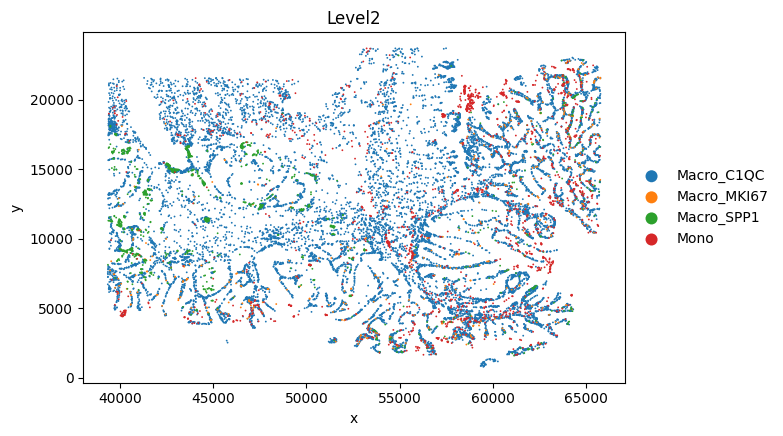

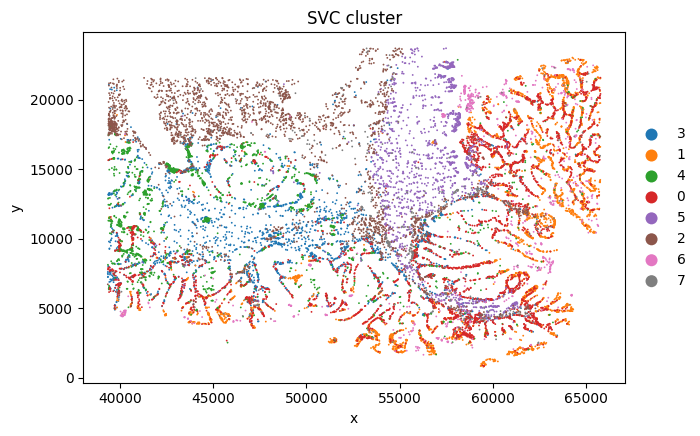

In [4]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors 

size = None
cmap = plt.cm.get_cmap('tab20', lut=10)
palette = [mcolors.to_hex(cmap(i)) for i in range(cmap.N)]

sc.pl.scatter(sc_svc_analysis.sc_SVC_adata_spatial, x="x", y="y",
              color='Level2',
              size=size)
desired_order = ['3','1','4','0','5','2','6','7'] # for better visualization
current_categories = sc_svc_analysis.sc_SVC_adata_spatial.obs['SVC_cluster'].cat.categories.astype(str).tolist()
ordered_categories = [cat for cat in desired_order if cat in current_categories]
ordered_categories += [cat for cat in current_categories if cat not in ordered_categories]
sc_svc_analysis.sc_SVC_adata_spatial.obs['SVC_cluster'] = (
    sc_svc_analysis.sc_SVC_adata_spatial.obs['SVC_cluster'].cat.reorder_categories(ordered_categories, ordered=True)
)
sc.pl.scatter(sc_svc_analysis.sc_SVC_adata_spatial, x="x", y="y",
              color='SVC_cluster',
              size=size)

## Where are the reconstructed TAM states located?

**Method and figure reading.** The maps use the spatial-side object and color the same Xenium coordinates by expert `Level2` annotation or sc-SVC cluster. Separate and side-by-side views are retained for orientation.

**Direct observation.** The reconstructed TAM clusters occupy different, partly overlapping spatial regions in this case. The maps do not themselves quantify co-localization or validate function.

**Paper context.** The paper interprets cluster 1 as TAM_1 T-cell-recruiting (the Inflammation branch used below), cluster 4 as TAM_2 SPP1+, cluster 0 as TAM_3 regulatory, and cluster 5 as the Normal comparator. Tissue-niche and prognostic interpretations use additional analyses beyond this map.


<Figure size 1000x800 with 0 Axes>

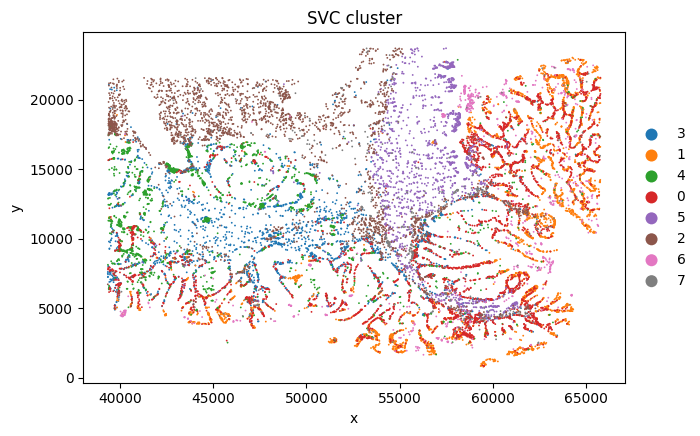

<Figure size 1000x1600 with 0 Axes>

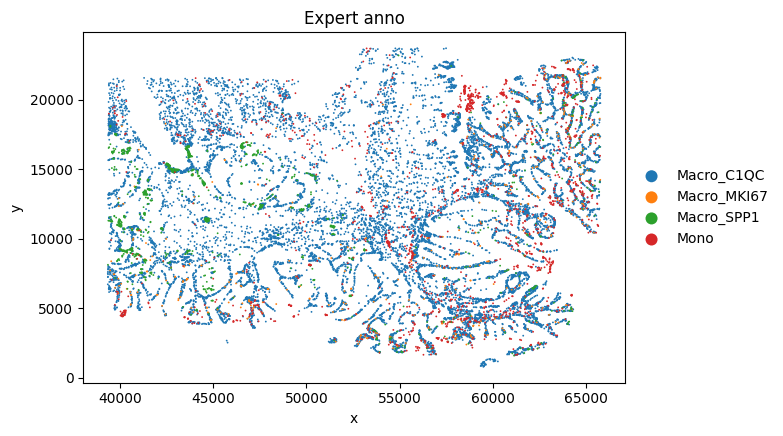

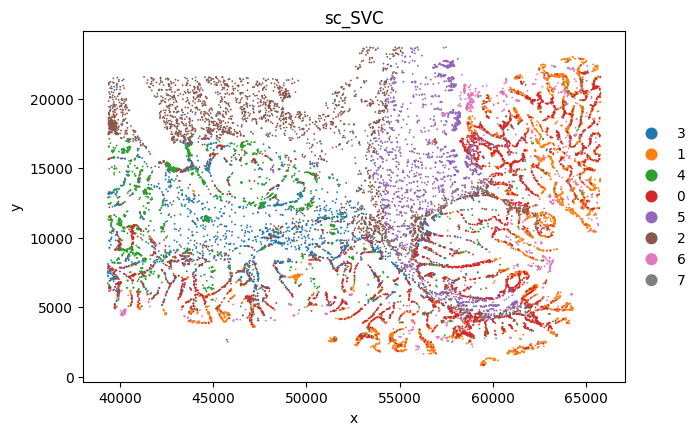

In [5]:
import matplotlib.pyplot as plt
def plot_sc_SVC(adata, color, title = None, file_name = None):

    colors = color if isinstance(color, (list, tuple)) else [color]
    titles = title if isinstance(title, (list, tuple)) else [title] * len(colors)
    plt.figure(figsize=(10, 8*len(colors)))
    for color_key, plot_title in zip(colors, titles):
        sc.pl.scatter(
            adata, x="x", y="y",
            color=color_key,
            title=plot_title, show=False,
        )
    plt.savefig(file_name, dpi = 300)
    plt.show()
    plt.close()

sc_SVC_file_name = f"{output_dir}/sc_SVC.png"
plot_sc_SVC(sc_svc_analysis.sc_SVC_adata_spatial, color='SVC_cluster',
            file_name=sc_SVC_file_name
            )

sc_SVC_file_name = f"{output_dir}/compare.png"
plot_sc_SVC(sc_svc_analysis.sc_SVC_adata_spatial, color=['Level2','SVC_cluster'],
            title=["Expert anno", "sc_SVC"],
            file_name=sc_SVC_file_name
            )

## Broad TAM differential and pathway overview

The full DEG table is retained as supporting evidence. Frozen local Hallmark enrichment then provides a broad functional overview for clusters 0, 1, and 4 before the curated marker panel and phenotype-level comparisons below. Returned terms describe this resource and run; a missing term is not evidence of absent pathway activity.


In [6]:
sc_svc_analysis.sc_SVC_degs.to_csv(f"{output_dir}/degs_all.csv")
sc_svc_analysis.sc_SVC_degs

,group,gene,logfoldchanges,pvals,pvals_adj,log_q
0,0,MMP12,6.157999,1.990059e-136,2.604589e-132,100.0
1,2,C1QB,2.797948,1.100503e-165,1.440339e-161,100.0
2,6,CTSZ,-3.827421,1.739723e-142,9.487289e-140,100.0
3,6,GPNMB,-4.479141,2.049615e-184,2.235447e-181,100.0
4,6,CD4,-3.998396,1.025761e-164,8.390727e-162,100.0
...,...,...,...,...,...,...
104699,2,SPHK2,-0.000144,9.998170e-01,1.000000e+00,-0.0
104700,2,NSMCE3,-0.000513,9.987000e-01,1.000000e+00,-0.0
104701,2,PRKCQ,-0.001938,9.986947e-01,1.000000e+00,-0.0
104702,2,THOC6,-0.000488,9.986390e-01,1.000000e+00,-0.0


In [7]:
fc_threshold = 1
pathway_num = 20
gene_num = 60
geneset_file = ["./pathway/h.all.v2025.1.Hs.symbols.gmt"]
pathway_file_name = f"{output_dir}/pathway_{fc_threshold}_{pathway_num}.txt"
cluster_nums = ['0', '1', '4']
all_pathway = sc_svc_analysis.get_pathway_conclusion(
    cluster_nums, fc_threshold=fc_threshold, pathway_num=pathway_num, gene_num=gene_num, geneset_file=geneset_file, normalize=False)
all_pathway.to_csv(pathway_file_name)
all_pathway

Conducting differential expression analysis...
Cluster 4: 
Up-regulated genes: ['SPP1', 'APOE', 'VIM', 'CHI3L1', 'CD9', 'CSTB', 'FBP1', 'GPNMB', 'FN1', 'APOC1', 'FTL', 'CD52', 'FTH1', 'LSP1', 'S100A6', 'SDC2', 'LGALS1', 'LPL', 'MARCO', 'NUPR1', 'S100A10', 'ANXA2', 'TIMP2', 'ANPEP', 'CTSK', 'APLP2', 'S100A11', 'LGALS3', 'OLR1', 'AQP9', 'CYP27A1', 'SPARC', 'ITGA5', 'GCHFR', 'NCF2', 'RGCC', 'RNASE1', 'FABP5', 'MMP7', 'EMP3', 'APOC2', 'S100A4', 'TSPO', 'CHIT1', 'CD82', 'LIPA', 'PLAUR', 'ITGB3', 'VAT1', 'EMP1', 'ZNF385A', 'COL6A2', 'S100A9', 'GLIPR2', 'SH3BGRL3', 'CD109', 'TREM2', 'FAM20C', 'SLC11A1', 'LTA4H']
Enriched pathways: ['HALLMARK_COAGULATION' 'HALLMARK_EPITHELIAL_MESENCHYMAL_TRANSITION'
 'HALLMARK_CHOLESTEROL_HOMEOSTASIS' 'HALLMARK_COMPLEMENT'
 'HALLMARK_ANGIOGENESIS' 'HALLMARK_INFLAMMATORY_RESPONSE'
 'HALLMARK_HYPOXIA' 'HALLMARK_APOPTOSIS'
 'HALLMARK_REACTIVE_OXYGEN_SPECIES_PATHWAY' 'HALLMARK_P53_PATHWAY'
 'HALLMARK_KRAS_SIGNALING_UP' 'HALLMARK_XENOBIOTIC_METABOLISM'
 'HALLMARK_U

,Gene_set,Term,Overlap,P-value,Adjusted P-value,Odds Ratio,Combined Score,Genes,group
6,h.all.v2025.1.Hs.symbols.gmt,HALLMARK_COAGULATION,10/138,5.445168e-07,0.000014,10.277426,148.235090,FN1;CTSK;SPARC;OLR1;APOC1;LTA4H;MMP7;APOC2;ITG...,4
8,h.all.v2025.1.Hs.symbols.gmt,HALLMARK_EPITHELIAL_MESENCHYMAL_TRANSITION,11/200,2.155354e-06,0.000027,7.753806,101.168209,FN1;ITGA5;COL6A2;SPARC;LGALS1;VIM;EMP3;SPP1;AN...,4
5,h.all.v2025.1.Hs.symbols.gmt,HALLMARK_CHOLESTEROL_HOMEOSTASIS,6/74,7.005318e-05,0.000584,10.813723,103.446837,S100A11;LGALS3;LPL;PLAUR;FABP5;CD9,4
7,h.all.v2025.1.Hs.symbols.gmt,HALLMARK_COMPLEMENT,9/200,1.043317e-04,0.000652,5.968101,54.715163,S100A9;FN1;TIMP2;OLR1;APOC1;LTA4H;LGALS3;PLAUR...,4
1,h.all.v2025.1.Hs.symbols.gmt,HALLMARK_ANGIOGENESIS,4/36,3.764051e-04,0.001882,15.106329,119.111056,LPL;OLR1;SPP1;S100A4,4
...,...,...,...,...,...,...,...,...,...
29,h.all.v2025.1.Hs.symbols.gmt,HALLMARK_UNFOLDED_PROTEIN_RESPONSE,1/113,6.404591e-01,0.706714,1.466147,0.653271,EDEM1,1
1,h.all.v2025.1.Hs.symbols.gmt,HALLMARK_ANDROGEN_RESPONSE,1/101,5.986879e-01,0.706714,1.645862,0.844351,PA2G4,1
18,h.all.v2025.1.Hs.symbols.gmt,HALLMARK_KRAS_SIGNALING_DN,1/200,8.394560e-01,0.839456,0.809784,0.141713,CD80,1
11,h.all.v2025.1.Hs.symbols.gmt,HALLMARK_GLYCOLYSIS,1/200,8.394560e-01,0.839456,0.809784,0.141713,IER3,1


## Which marker programs distinguish the focal TAM states?

**Method and figure reading.** The first dot plot shows automatic top DEGs as supporting evidence. The curated panel emphasizes SPP1/CSTB/CHI3L1 for cluster 4, regulatory/macrophage markers for cluster 0, and IL7R/CXCL9/CXCL10/ADAM19 for cluster 1.

**Direct observation.** The current output separates SPP1-associated, regulatory, and recruiting-inflammatory marker programs across the focal TAM clusters.

**Paper context.** These clusters are described as TAM_2 SPP1+, TAM_3 regulatory, and TAM_1 recruiting-inflammatory. Their proposed ecosystem and clinical roles depend on analyses outside this marker block.


Conducting differential expression analysis...


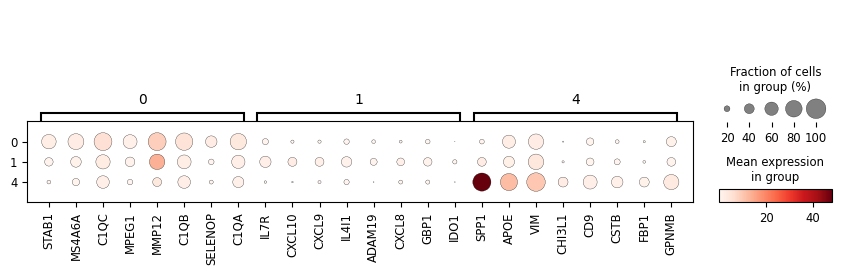

In [8]:
cluster_nums = ['0', '1', '4']

degs = sc_svc_analysis.get_svc_degs(cluster_nums, 1)

marker_dict = (
    degs.groupby('group')['gene']
    .apply(lambda x: x.head(8).tolist())
    .to_dict()
)
sc_svc_analysis.get_dot_plot(cluster_nums, marker_dict)

<Figure size 800x600 with 0 Axes>

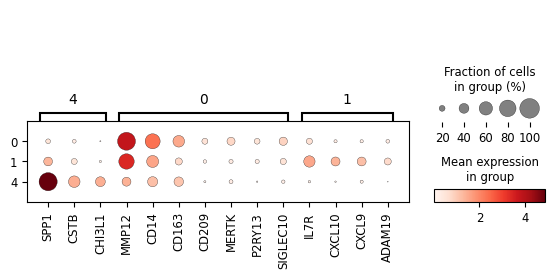

<Figure size 640x480 with 0 Axes>

In [9]:
import matplotlib as mpl
import matplotlib.pyplot as plt

mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.useafm'] = False
plt.figure(figsize=(8, 6))

marker_dict = {
    '4': ['SPP1', 'CSTB', 'CHI3L1'], 
    '0': [
        'MMP12', 
        'CD14',      
        'CD163',     
        'CD209',     
        'MERTK',     
        'P2RY13',    
        'SIGLEC10',  
    ],
    '1': [
        'IL7R', 
        'CXCL10', 
        'CXCL9', 
        'ADAM19' 
    ]
}

sc_svc_analysis.get_dot_plot(cluster_nums, marker_dict, normalize=True)
plt.savefig(f"{output_dir}/sc_SVC_dotplot.pdf", dpi=300, bbox_inches='tight')
plt.show()
plt.close()

## How do TAM spatial-side and expression-side DEG results compare?

**Design.** Two predefined supporting comparisons are run on both SVC objects: cluster 1 Inflammation versus cluster 5, and cluster 0 Regulation versus cluster 5. The two objects share phenotype semantics but contain different observations and gene spaces, so this is not a paired-cell before/after test.

**How to read the outputs.** Each phenotype and side writes its own DEG table, volcano plot, and frozen local enrichment table. The volcano display uses the recorded thresholds in the code cell below; the artifact paths keep the four branches separate.

**Direct observation.** The four retained branches provide distinct spatial-side and expression-side DEG/enrichment results for the two predefined TAM phenotypes.

**Paper context.** The paper uses expanded expression programs and spatial organization to interpret TAM heterogeneity. This supporting comparison does not by itself validate those biological labels or establish method superiority.


Conducting differential expression analysis...
Conducting differential expression analysis...
Conducting differential expression analysis...
Conducting differential expression analysis...


1100

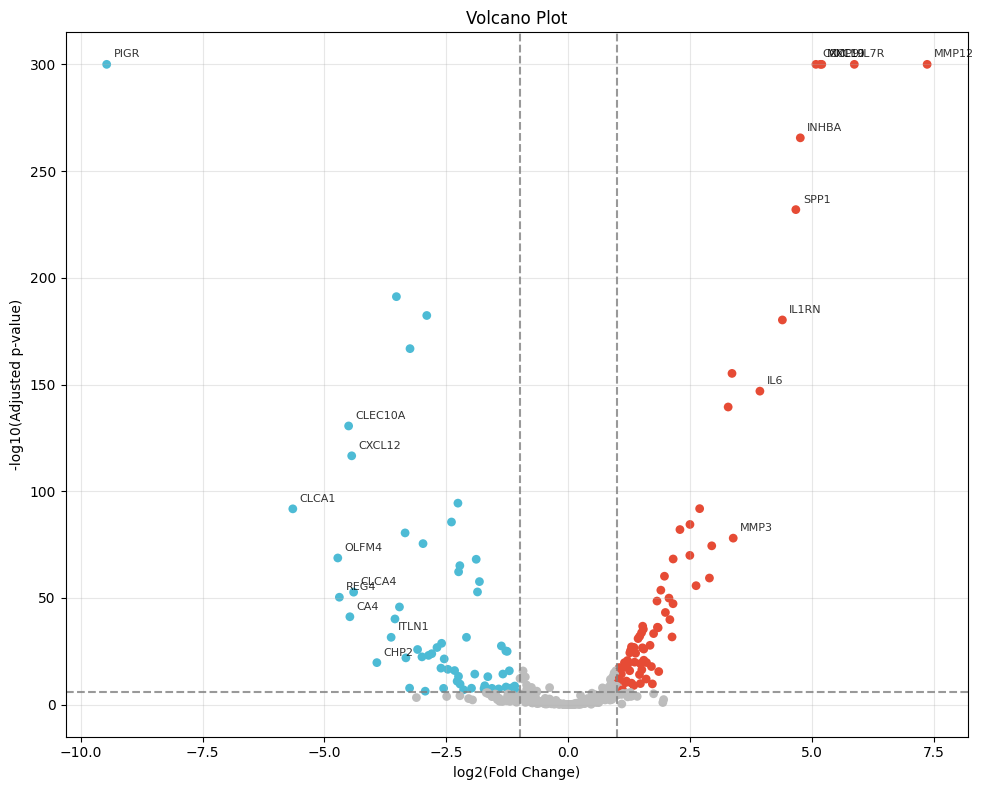

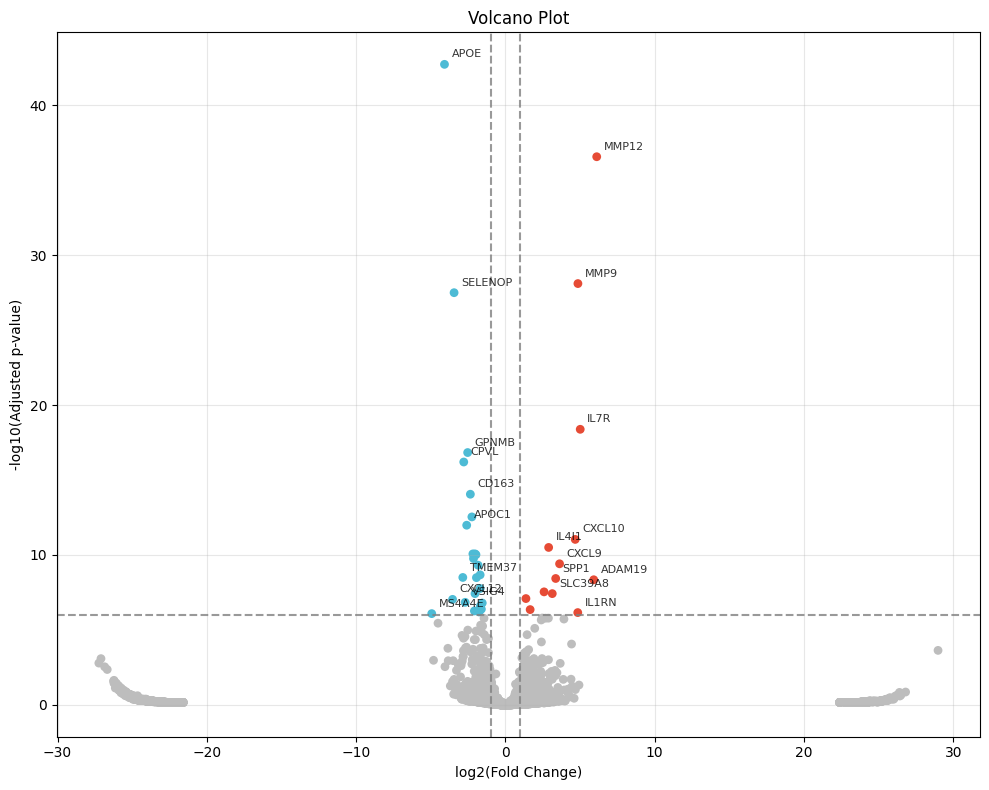

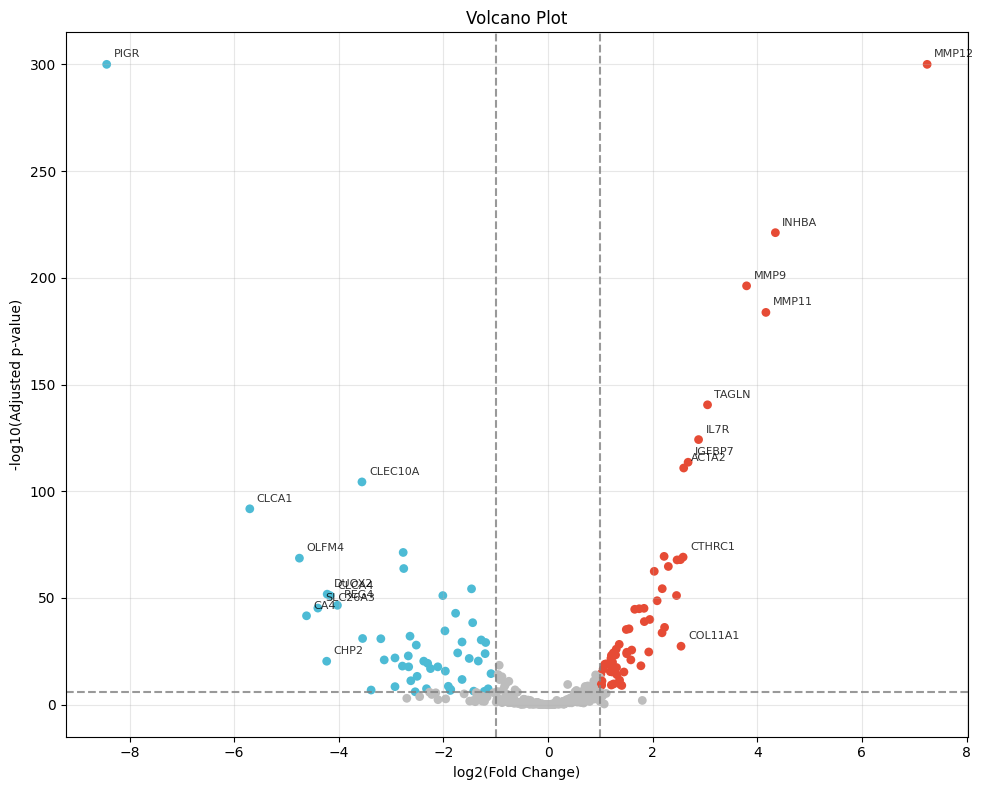

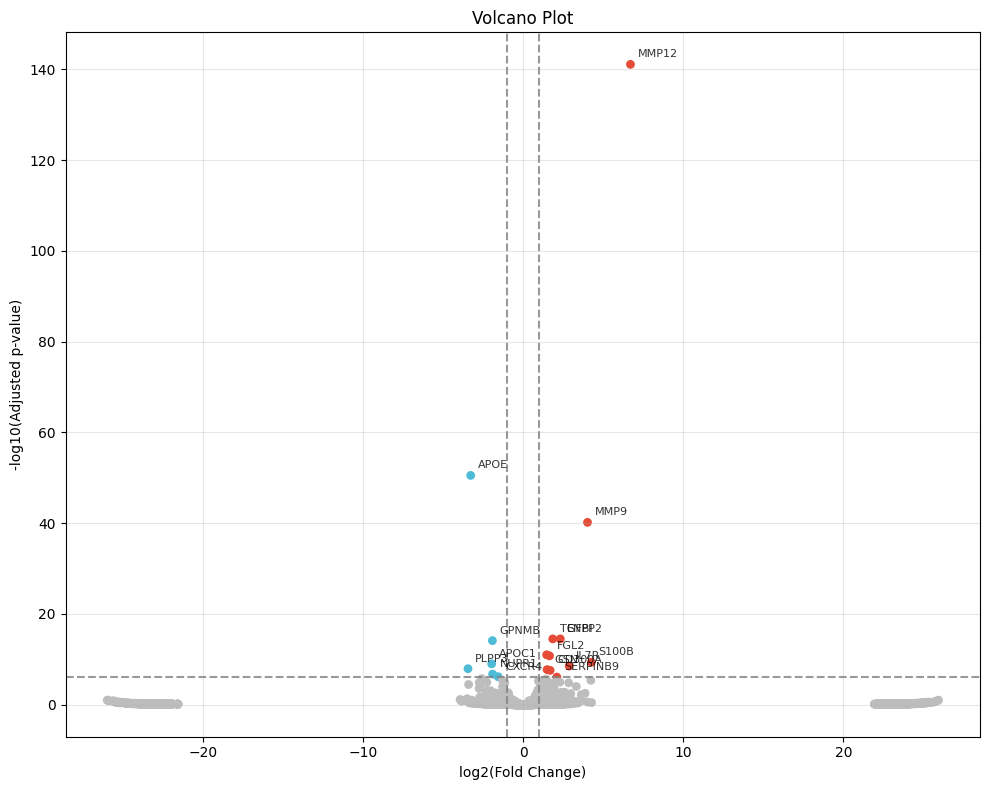

In [10]:
comparison_specs = [("1", "Inflammation"), ("0", "Regulation")]
normal_cluster = "5"
comparison_datasets = {
    "spatial": sc_svc_analysis.sc_SVC_adata_spatial.copy(),
    "expr": sc_svc_analysis.sc_SVC_adata_expr.copy(),
}

from datetime import datetime, timezone
import hashlib
import json
from pathlib import Path
from revise.analysis.bio import get_degs, get_enrichment, plot_volcano

local_resources = [{
    "id": "hallmark_gmt",
    "path": "reproduce/case/pathway/h.all.v2025.1.Hs.symbols.gmt",
    "sha256": hashlib.sha256(Path(geneset_file[0]).read_bytes()).hexdigest(),
}]
local_enrichment_runs = []
for tumor_cluster_num, phenotype in comparison_specs:
    for dataset_name in ("spatial", "expr"):
        comparison_output_dir = f"{output_dir}/comparisons/{phenotype}/{dataset_name}"
        Path(comparison_output_dir).mkdir(parents=True, exist_ok=True)
        comparison_adata = comparison_datasets[dataset_name]
        comparison_adata = comparison_adata[
            comparison_adata.obs["SVC_cluster"].astype(str).isin(
                [normal_cluster, tumor_cluster_num]
            )
        ].copy()
        comparison_adata.obs["SVC_cluster"] = (
            comparison_adata.obs["SVC_cluster"].astype(str).replace({
                normal_cluster: "Normal-infiltrated",
                tumor_cluster_num: "Tumor-infiltrated",
            })
        )
        degs = get_degs(
            comparison_adata,
            groupby="SVC_cluster",
            method="t-test",
            fc_threshold=None,
        )
        degs = degs[degs["group"] == "Tumor-infiltrated"].reset_index(drop=True)
        degs.to_csv(f"{comparison_output_dir}/degs.csv", index=False)
        plot_volcano(
            degs,
            logfc_threshold=1,
            padj_threshold=1e-6,
            top_k=10,
            save_file_name=f"{comparison_output_dir}/volcano.pdf",
        )
        started_at = datetime.now(timezone.utc).isoformat()
        pathway = get_enrichment(
            degs.loc[degs["logfoldchanges"] > 0, "gene"].head(60).tolist(),
            geneset_file,
            background=None,
        )
        pathway.to_csv(f"{comparison_output_dir}/pathway.csv", index=False)
        local_enrichment_runs.append({
            "phenotype": phenotype,
            "dataset": dataset_name,
            "started_at": started_at,
            "completed_at": datetime.now(timezone.utc).isoformat(),
        })

Path(f"{output_dir}/integration-evidence.json").write_text(
    json.dumps({
        "provider": "GSEApy local enrich",
        "background": None,
        "background_policy": "GSEApy default over local GMT union",
        "resources": local_resources,
        "runs": local_enrichment_runs,
    }, indent=2, sort_keys=True) + "\n",
    encoding="utf-8",
)


## Which preselected ligand–receptor pairs are supported by CellPhoneDB?

**Question and scope.** This block examines five paper-driven, preselected ligand–receptor pairs across the regulatory pair T_5 (paper T_3) / TAM_0 (paper TAM_3) and the recruiting pair T_1 (paper T_0) / TAM_1 (paper TAM_1). It uses T and Mono expression-side cells and **does not use spatial distance**.

**Method.** `run_cellphonedb_v5` executes the recorded CellPhoneDB v5 parameters and returns raw tables. `normalize_cellphonedb_tables` validates and aligns `pvalues`, `significant_means`, and `interaction_scores` on their actual directional cell-pair axis. The intermediate key/count displays are retained as collapsible technical evidence; the normalized five-pair tables and dot plot are the result consumed below.

**Figure reading.** The final dot plot uses `significant_means` for color and CellPhoneDB p-values for point size. Rows are the five preselected pairs; columns are directional source–target group pairs.

**Direct observation.** The retained outputs report directional CellPhoneDB statistics for ANXA1_FPR3, LTB_LTBR, CXCL10_CXCR3, CXCL9_CXCR3, and CCL5_CCR1 in the four predefined groups. This does not establish causal communication, spatial co-localization, or unbiased LR discovery.

**Paper context.** The paper discusses these candidate axes in relation to regulatory and recruiting immune niches, TLS activity, and prognosis. Those spatial and clinical claims rely on additional analyses not reproduced in this CCI block.


In [11]:
output_dir

'../../output/P2CRC_Xenium/Mono'

In [13]:
import scanpy as sc

T_SVC_adata = sc.read("../../results/sc_SVC_case/P2CRC_Xenium/T/expr.h5ad")
T_SVC_adata = T_SVC_adata[T_SVC_adata.obs['SVC_cluster'].isin(['1','5'])]
# T_SVC_adata = T_SVC_adata[T_SVC_adata.obs['SVC_cluster'].isin(['0','1','5'])]

T_SVC_adata.obs['SVC_cluster'] = [f"T_{i}" for i in T_SVC_adata.obs['SVC_cluster']]

TAM_SVC_adata = sc.read("../../results/sc_SVC_case/P2CRC_Xenium/Mono_Macro/expr.h5ad")
TAM_SVC_adata = TAM_SVC_adata[TAM_SVC_adata.obs['SVC_cluster'].isin(['0','1'])]
TAM_SVC_adata.obs['SVC_cluster'] = [f"TAM_{i}" for i in TAM_SVC_adata.obs['SVC_cluster']]

adata = T_SVC_adata.concatenate(TAM_SVC_adata)
adata

AnnData object with n_obs × n_vars = 1686 × 13088
    obs: 'Level1', 'Level2', 'SVC_cluster', 'max_score', 'batch'
    var: 'gene_ids', 'feature_types', 'genome', 'n_cells'
    obsm: 'SVC_cluster'

In [14]:
adata.obs['SVC_cluster'].value_counts()

SVC_cluster
T_5      857
TAM_0    361
T_1      287
TAM_1    181
Name: count, dtype: int64

In [15]:
celltype_key = "SVC_cluster"
from pathlib import Path
from revise.analysis.advanced.cell_communication import run_cellphonedb_v5
cpdb_path = Path('./CCI/cellphonedb.zip')
cpdb_results, adata_cpdb = run_cellphonedb_v5(
    adata,
    database_path=cpdb_path,
    celltype_key=celltype_key,
    min_cell_fraction=0.005,             
    min_genes=200,                       
    min_cells=3,                         
    iterations=1000,                     
    threshold=0.1,                       
    pvalue=0.05,                         
    threads=10,                          
    output_dir=f'{output_dir}/cpdb_results',         
    cleanup_temp=True                    
)

🔬 Starting CellPhoneDB analysis...
✅ Valid CellPhoneDB database found: CCI/cellphonedb.zip (0.1 MB)
   - Original data: 1686 cells, 13088 genes
   - Cell types passing 0.5% threshold: 4
   - Minimum cells required: 8
   - After filtering: 1686 cells, 13088 genes
   - After preprocessing: 1686 cells, 12249 genes
   - Temporary directory: /var/folders/fd/3dt4wzz12bx4ycmm4k_gp_km0000gn/T/cpdb_temp_8buvhad1
   - Output directory: /Users/stephen/Documents/wuyushuai_project/wuyushuai_research_project/REVISE/output/notebook_analysis_acceptance/Monocyte/20260814T130000Z-display/analysis/cpdb_results
   - Created temporary input files


   - Running CellPhoneDB statistical analysis...
Reading user files...


The following user files were loaded successfully:
/var/folders/fd/3dt4wzz12bx4ycmm4k_gp_km0000gn/T/cpdb_temp_8buvhad1/counts_matrix.h5ad
/var/folders/fd/3dt4wzz12bx4ycmm4k_gp_km0000gn/T/cpdb_temp_8buvhad1/metadata.tsv
[ ][CORE][14/08/26-00:37:34][INFO] [Cluster Statistical Analysis] Threshold:0.1 Iterations:1000 Debug-seed:42 Threads:10 Precision:3


[ ][CORE][14/08/26-00:37:34][WARNING] Debug random seed enabled. Set to 42


[ ][CORE][14/08/26-00:37:35][INFO] Running Real Analysis


...

[ ][CORE][14/08/26-00:37:43][INFO] Scoring interactions: Filtering genes per cell type..


[ ][CORE][14/08/26-00:37:43][INFO] Scoring interactions: Calculating mean expression of each gene per group/cell type..


[ ][CORE][14/08/26-00:37:44][INFO] Scoring interactions: Calculating scores for all interactions and cell types..


/private/tmp/revise-notebook-acceptance-v5-venv/lib/python3.10/site-packages/torch/cuda/__init__.py:64: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]
/private/tmp/revise-notebook-acceptance-v5-venv/lib/python3.10/site-packages/torch/cuda/__init__.py:64: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]
/private/tmp/revise-notebook-acceptance-v5-venv/lib/python3.10/site-packages/torch/cuda/__init__.py:64: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that inst

Saved deconvoluted to /Users/stephen/Documents/wuyushuai_project/wuyushuai_research_project/REVISE/output/notebook_analysis_acceptance/Monocyte/20260814T130000Z-display/analysis/cpdb_results/statistical_analysis_deconvoluted_08_14_2026_003747.txt
Saved deconvoluted_percents to /Users/stephen/Documents/wuyushuai_project/wuyushuai_research_project/REVISE/output/notebook_analysis_acceptance/Monocyte/20260814T130000Z-display/analysis/cpdb_results/statistical_analysis_deconvoluted_percents_08_14_2026_003747.txt
Saved means to /Users/stephen/Documents/wuyushuai_project/wuyushuai_research_project/REVISE/output/notebook_analysis_acceptance/Monocyte/20260814T130000Z-display/analysis/cpdb_results/statistical_analysis_means_08_14_2026_003747.txt
Saved pvalues to /Users/stephen/Documents/wuyushuai_project/wuyushuai_research_project/REVISE/output/notebook_analysis_acceptance/Monocyte/20260814T130000Z-display/analysis/cpdb_results/statistical_analysis_pvalues_08_14_2026_003747.txt
Saved significant_

In [16]:
cpdb_results.keys()

dict_keys(['deconvoluted', 'deconvoluted_percents', 'means', 'pvalues', 'significant_means', 'CellSign_active_interactions', 'CellSign_active_interactions_deconvoluted', 'interaction_scores'])

In [17]:
select_clusters = ['T_5','TAM_0']
df = cpdb_results['significant_means']
df = cpdb_results['interaction_scores']
df
# df = df[(df['source'].isin(select_clusters)) & (df['target'].isin(select_clusters))]
# df_sorted = df.sort_values('mean', ascending=False)
# df_sorted

,id_cp_interaction,interacting_pair,partner_a,partner_b,gene_a,gene_b,secreted,receptor_a,receptor_b,annotation_strategy,...,TAM_1|T_1,TAM_1|T_5,T_1|TAM_0,T_1|TAM_1,T_1|T_1,T_1|T_5,T_5|TAM_0,T_5|TAM_1,T_5|T_1,T_5|T_5
0,CPI-SC0A2DB962D,CDH1_integrin_a2b1_complex,simple:P12830,complex:integrin_a2b1_complex,CDH1,NaN,False,False,False,curated,...,0.0,0.0,0.0,0.000,0.0,0.0,0.000,0.000,0.0,0.0
2,CPI-SC0C8B7BCBB,COL11A1_integrin_a2b1_complex,simple:P12107,complex:integrin_a2b1_complex,COL11A1,NaN,True,False,False,curated,...,0.0,0.0,0.0,0.000,0.0,0.0,0.000,0.000,0.0,0.0
4,CPI-SC0B86B7CED,COL12A1_integrin_a2b1_complex,simple:Q99715,complex:integrin_a2b1_complex,COL12A1,NaN,True,False,False,curated,...,0.0,0.0,0.0,0.000,0.0,0.0,0.000,0.000,0.0,0.0
6,CPI-SC0CCCF9A7F,COL14A1_integrin_a2b1_complex,simple:Q05707,complex:integrin_a2b1_complex,COL14A1,NaN,True,False,False,curated,...,0.0,0.0,0.0,0.000,0.0,0.0,0.000,0.000,0.0,0.0
7,CPI-SC0E85E1FB0,COL15A1_integrin_a2b1_complex,simple:P39059,complex:integrin_a2b1_complex,COL15A1,NaN,True,False,False,curated,...,0.0,0.0,0.0,0.000,0.0,0.0,0.000,0.000,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2899,CPI-SS0822AEF5F,PTPRC_MRC1,simple:P08575,simple:P22897,PTPRC,MRC1,False,False,True,curated,...,0.0,0.0,100.0,40.149,0.0,0.0,35.727,14.344,0.0,0.0
2900,CPI-SS096F8C268,PTPRD_IL1RAP,simple:P23468,simple:Q9NPH3,PTPRD,IL1RAP,True,True,True,curated,...,0.0,0.0,0.0,0.000,0.0,0.0,0.000,0.000,0.0,0.0
2905,CPI-SS016FD0C8A,RNASET2_TLR8,simple:O00584,simple:Q9NR97,RNASET2,TLR8,True,False,True,curated,...,0.0,0.0,0.0,0.000,0.0,0.0,0.000,0.000,0.0,0.0
2907,CPI-SS02A170A99,SPN_SIGLEC1,simple:P16150,simple:Q9BZZ2,SPN,SIGLEC1,True,False,False,curated,...,0.0,0.0,0.0,0.000,0.0,0.0,0.000,0.000,0.0,0.0


In [18]:
cpdb_results.keys()
deconvoluted_percents = cpdb_results['deconvoluted_percents']

In [19]:
select_LR_pairs = [
    'ANXA1_FPR3','LTB_LTBR',
    'CXCL10_CXCR3','CXCL9_CXCR3', 
    'CCL5_CCR1',
]

In [20]:
from revise.analysis.advanced.cell_communication import normalize_cellphonedb_tables

cell_groups = ["T_1", "T_5", "TAM_0", "TAM_1"]
if set(adata.obs['SVC_cluster'].astype(str).unique()) != set(cell_groups):
    raise ValueError("CellPhoneDB input groups do not match the four-group contract")
print(cell_groups)

cpdb_tables = normalize_cellphonedb_tables(cpdb_results, cell_groups)
pvals = cpdb_tables['pvalues'].loc[select_LR_pairs]

# significant_means
significant_means = cpdb_tables['significant_means'].loc[select_LR_pairs]

interaction_scores = cpdb_tables['interaction_scores'].loc[select_LR_pairs]

interaction_scores
from pathlib import Path
cpdb_checkpoint_dir = Path(output_dir) / "cellphonedb"
cpdb_checkpoint_dir.mkdir(parents=True, exist_ok=True)
for table_name, table in cpdb_results.items():
    if table_name in ("pvalues", "significant_means", "interaction_scores"):
        table.to_csv(cpdb_checkpoint_dir / f"{table_name}.csv", index=False)
normalized_selected_lr = pvals.reset_index()[["LR_pair"]].rename(columns={"LR_pair": "pair"})
normalized_selected_lr[["gene_a", "gene_b"]] = normalized_selected_lr["pair"].str.split("_", n=1, expand=True)
normalized_selected_lr[["gene_a", "gene_b", "pair"]].to_csv(
    cpdb_checkpoint_dir / "normalized_selected_lr.csv", index=False
)
for selected_table in (pvals, significant_means, interaction_scores):
    selected_table.index.name = "pair"
    selected_table.columns.name = "cell_pair"
selected_lr_consumption = pd.concat({
    "pvalue": pvals.stack(dropna=False),
    "significant_mean": significant_means.stack(dropna=False),
    "interaction_score": interaction_scores.stack(dropna=False),
}, axis=1).reset_index()
selected_lr_consumption.to_csv(
    cpdb_checkpoint_dir / "selected_lr_consumption.csv", index=False
)
import hashlib
import importlib.metadata
import json
(cpdb_checkpoint_dir / "evidence.json").write_text(
    json.dumps({
        "provider": "CellPhoneDB",
        "provider_version": importlib.metadata.version("cellphonedb"),
        "database": {
            "path": "reproduce/case/CCI/cellphonedb.zip",
            "sha256": hashlib.sha256(cpdb_path.read_bytes()).hexdigest(),
        },
        "celltype_key": celltype_key,
        "cell_groups": cell_groups,
        "parameters": {
            "min_cell_fraction": 0.005,
            "min_genes": 200,
            "min_cells": 3,
            "iterations": 1000,
            "threshold": 0.1,
            "pvalue": 0.05,
            "threads": 10,
            "cleanup_temp": True,
        },
        "selected_lr_pairs": select_LR_pairs,
        "raw_tables": ["pvalues", "significant_means", "interaction_scores"],
        "normalized_checkpoint": "cellphonedb/normalized_selected_lr.csv",
        "consumption_checkpoint": "cellphonedb/selected_lr_consumption.csv",
    }, indent=2, sort_keys=True) + "\n",
    encoding="utf-8",
)


['T_1', 'T_5', 'TAM_0', 'TAM_1']


873

In [21]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.colors as mcolors
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

import matplotlib as mpl
import matplotlib.pyplot as plt

mpl.rcParams['pdf.fonttype'] = 42      
mpl.rcParams['ps.useafm'] = False     
def LR_pair_dotplot(scores, pvals, cmap='RdBu_r', pval_cutoff=0.1, save_file_name=None):
    
    row_names = scores.index.tolist()
    col_names = scores.columns.tolist()
    scores = np.array(scores)
    pvals = np.array(pvals)
    
    score_min = np.nanmin(scores)
    score_max = np.nanmax(scores)
    
    log_pvals = -np.log10(pvals + 1e-20)  
    
    size_mask = pvals >= pval_cutoff
    log_pvals_filtered = log_pvals.copy()
    log_pvals_filtered[size_mask] = 0  
    
    min_size = 20
    max_size = 200
    
    significant_log_pvals = log_pvals_filtered[log_pvals_filtered > 0]
    if len(significant_log_pvals) > 0:
        min_sig_pval = np.min(significant_log_pvals)
        max_sig_pval = np.max(significant_log_pvals)
    else:
        min_sig_pval = 1  
        max_sig_pval = 3  
    
    sizes = np.zeros_like(log_pvals_filtered)
    significant_mask = log_pvals_filtered > 0
    sizes[significant_mask] = np.interp(
        log_pvals_filtered[significant_mask], 
        (min_sig_pval, max_sig_pval), 
        (min_size, max_size)
    )
    
    fig, ax = plt.subplots(figsize=(10,4))
    
    # Plot each point (with the y-axis inverted)
    for i in range(scores.shape[0]):
        for j in range(scores.shape[1]):
            if not np.isnan(scores[i, j]) and not np.isnan(pvals[i, j]):
                if sizes[i, j] > 0:  

                    ax.scatter(j, len(row_names)-1-i, 
                              c=[scores[i, j]], 
                              s=sizes[i, j], 
                              cmap=cmap, 
                              alpha=0.7,
                              edgecolors='black', 
                              linewidth=0.5,
                              vmin=score_min, 
                              vmax=score_max)
    
    ax.set_xticks(range(len(col_names)))
    ax.set_xticklabels(col_names, rotation=45, ha='right', fontsize=10)
    
    ax.set_yticks(range(len(row_names)))
    ax.set_yticklabels(row_names[::-1], fontsize=10)
    ax.set_xlim(-0.5, len(col_names)-0.5)
    ax.set_ylim(-0.5, len(row_names)-0.5)
    
    ax.grid(True, alpha=0.3, linestyle='-', linewidth=0.5)
    ax.set_axisbelow(True)
    
    norm = mcolors.Normalize(vmin=score_min, vmax=score_max)
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    cbar = plt.colorbar(sm, ax=ax, shrink=0.5, aspect=20, pad=0.02)
    cbar.set_label('Scores', rotation=270, labelpad=15)
    
    if len(significant_log_pvals) > 0:
        use_power_scale = (max_sig_pval / min_sig_pval > 100) and (max_sig_pval > 10)
        
        if use_power_scale:
            min_power = 0  
            max_power = np.ceil(np.log10(max_sig_pval))  
            
            representative_log_pvals = [10**power for power in range(int(min_power), int(max_power)+1)]
            
            representative_log_pvals = [x for x in representative_log_pvals 
                                      if x <= max_sig_pval * 1.1]  
        else:
            num_points = min(5, max(2, int(max_sig_pval - min_sig_pval) + 1))
            representative_log_pvals = np.linspace(min_sig_pval, max_sig_pval, num_points)
        
        representative_log_pvals = [x for x in representative_log_pvals 
                                   if min_sig_pval <= x <= max_sig_pval * 1.1]
        
        representative_log_pvals = sorted(set(representative_log_pvals))
        
        if not representative_log_pvals:
            representative_log_pvals = [min_sig_pval, max_sig_pval]
        
        representative_sizes = np.interp(representative_log_pvals, 
                                       (min_sig_pval, max_sig_pval), 
                                       (min_size, max_size))
        
        legend_elements = []
        for log_pval, size in zip(representative_log_pvals, representative_sizes):
            if log_pval >= 100 or (log_pval >= 1 and log_pval == int(log_pval)):
                label = f'-log10(p) = {log_pval:.0f}'
            elif log_pval >= 10:
                label = f'-log10(p) = {log_pval:.1f}'
            else:
                label = f'-log10(p) = {log_pval:.2f}'
            
            legend_elements.append(Line2D([0], [0], 
                                        marker='o', 
                                        color='w', 
                                        markerfacecolor='gray',
                                        markersize=np.sqrt(size)/2,
                                        markeredgecolor='black',
                                        label=label))
    else:
        legend_elements = [Line2D([0], [0], marker='o', color='w', markerfacecolor='gray',
                                markersize=0, label='No significant points')]
    
    significance_legend = ax.legend(handles=legend_elements, 
                                  loc='upper left', 
                                  bbox_to_anchor=(1.02, 1.0),
                                  title='Significance',
                                  frameon=True,
                                  fancybox=True,
                                  shadow=True,
                                  fontsize=9)
    
    ax.set_xlabel('Cell pairs', fontsize=12)
    ax.set_ylabel('LR pairs', fontsize=12)
    ax.set_title(f'LR Pair Dot Plot', fontsize=14, pad=20)
    
    plt.tight_layout(rect=[0, 0, 0.85, 1])
    
    if save_file_name:
        plt.savefig(save_file_name, dpi=300, bbox_inches='tight')
    else:
        plt.show()

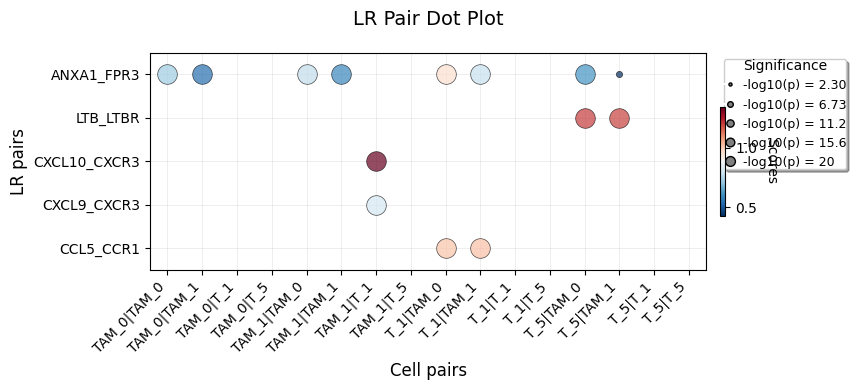

In [22]:
scores = interaction_scores.copy()
scores = significant_means.copy()

save_file_name = None
save_file_name = f"{output_dir}/LR_pair_dotplot.pdf"
LR_pair_dotplot(scores, pvals, save_file_name = save_file_name)
